In [1]:
 #General Libraries
import numpy as np                    # For numerical computations
import pandas as pd                   # For handling dataframes

# Data Visualization
import matplotlib.pyplot as plt       # For plotting graphs
import seaborn as sns                 # For advanced plots

# Preprocessing
from sklearn.preprocessing import StandardScaler,PolynomialFeatures,LabelEncoder, OneHotEncoder# For feature scaling
from sklearn.model_selection import train_test_split ,GridSearchCV # For splitting the dataset

# Regression Models
from sklearn.linear_model import LinearRegression      # Model 1: Linear Regression
from sklearn.tree import DecisionTreeRegressor         # Model 2: Decision Tree Regression
from sklearn.ensemble import RandomForestRegressor     # Model 3: Random Forest Regression
from sklearn.svm import SVR
# Classification Models
from sklearn.linear_model import LogisticRegression     # Model 1: Logistic Regression (Classification)
from sklearn.tree import DecisionTreeClassifier         # Model 2: Decision Tree Classifier
from sklearn.ensemble import RandomForestClassifier     # Model 3: Random Forest Classifier

# Evaluation Metrics - Regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Evaluation Metrics - Classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [2]:
# تحميل البيانات
data = pd.read_csv(r"archive 0/medical_insurance.csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


# Explore Data

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [5]:
data.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


# Preprocession

In [6]:
#missing values
data.isnull().sum().sum()

np.int64(0)

In [7]:
#checking for duplicates
data.duplicated().sum()

np.int64(1435)

In [8]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [9]:
# convert the categorical to numerical data
numerical_data = data.select_dtypes(include=[np.int64,np.float64]).columns
categorical_data = data.select_dtypes(include=[np.object_]).columns
for col in categorical_data:
    data[col] = data[col].astype('category').cat.codes
data.head()



C:\Users\DELL\AppData\Local\Temp\ipykernel_13468\2376503320.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = data[col].astype('category').cat.codes
C:\Users\DELL\AppData\Local\Temp\ipykernel_13468\2376503320.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = data[col].astype('category').cat.codes
C:\Users\DELL\AppData\Local\Temp\ipykernel_13468\2376503320.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


Number of outliers in 'loan_amnt': 139


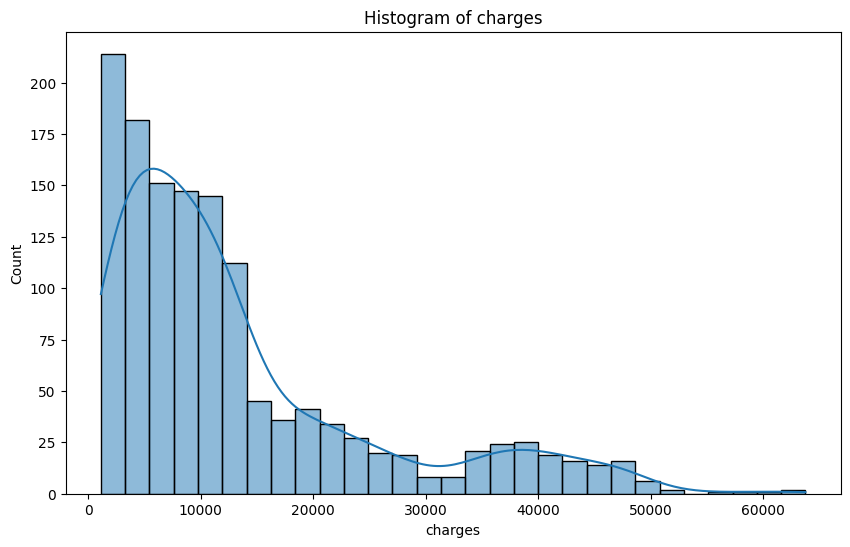

In [10]:
#chick for outliers

Q1 = data['charges'].quantile(0.25)
Q3 = data['charges'].quantile(0.75)   
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['charges'] < lower_bound) | (data['charges'] > upper_bound)]
print(f"Number of outliers in 'loan_amnt': {outliers.shape[0]}")

# Visualize outliers using a box plot
plt.figure(figsize=(10, 6))     
sns.histplot(x=data['charges'], kde=True)
plt.title('Histogram of charges')
plt.xlabel('charges')   
plt.show()



C:\Users\DELL\AppData\Local\Temp\ipykernel_13468\4273106486.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['charges'] = data['charges'].clip(lower_bound, upper_bound)


Number of outliers in 'charges' after clipping: 0


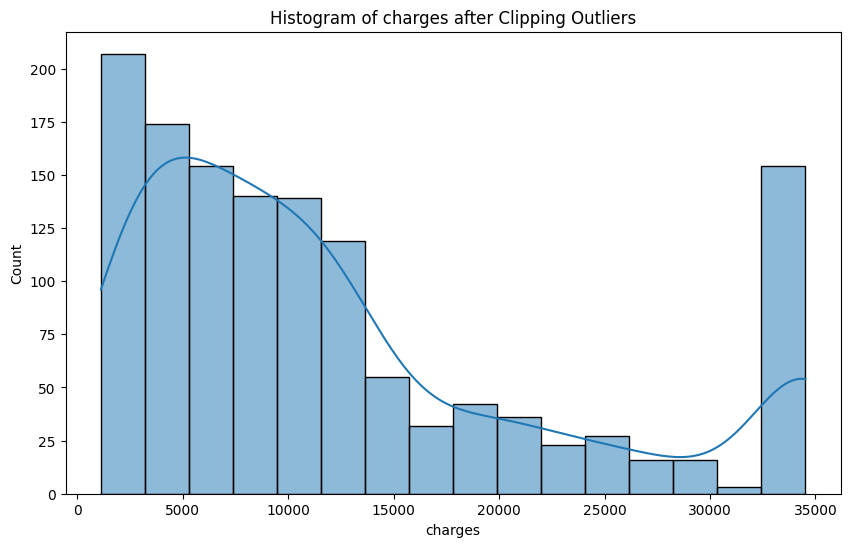

In [11]:
# after clipping for outliers 
data['charges'] = data['charges'].clip(lower_bound, upper_bound)
print(f"Number of outliers in 'charges' after clipping: {data[(data['charges'] < lower_bound) | (data['charges'] > upper_bound)].shape[0]}")
plt.figure(figsize=(10, 6))
sns.histplot(x=data['charges'], kde=True) 
plt.title('Histogram of charges after Clipping Outliers')
plt.xlabel('charges')
plt.show()


In [12]:
# اختيار الأعمدة العددية فقط

# فحص skewness قبل التحويل
print("Skewness BEFORE transformation:\n")

for col in numerical_data:
    if data[col].nunique() > 2:   # تجاهل الأعمدة الثنائية
        print(col, ":", data[col].skew())

print("\nApplying log transformation...\n")

# معالجة skewness
for col in numerical_data:

    # تجاهل الأعمدة الثنائية
    if data[col].nunique() <= 2:
        continue

    skew_val = data[col].skew()

    # تطبيق log فقط إذا كان skew كبير
    if abs(skew_val) > 1:

        # إزالة القيم المفقودة قبل الفحص
        if (data[col].dropna() >= 0).all():

            data[col] = np.log1p(data[col])

            print(col, "transformed")
            print("New skew:", data[col].skew())
            print("-------------------")

Skewness BEFORE transformation:

age : 0.054780773126998195
bmi : 0.28391419385321137
children : 0.9374206440474123
charges : 1.0846971962484675

Applying log transformation...

charges transformed
New skew: -0.2227854299015869
-------------------


C:\Users\DELL\AppData\Local\Temp\ipykernel_13468\1864126831.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = np.log1p(data[col])


# Visualization

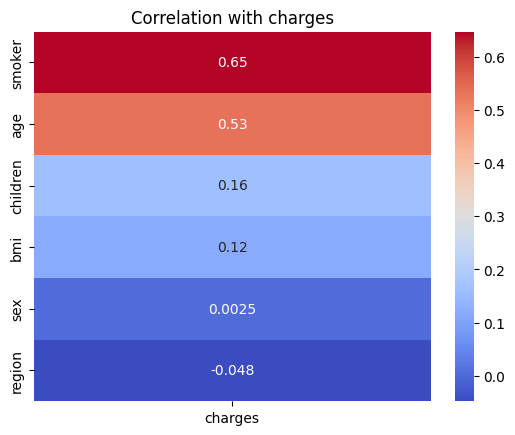

In [13]:

# Correlation Series
corr = data.corr()['charges'].drop('charges').sort_values(ascending=False)

# Convert to DataFrame for heatmap
corr_df = corr.to_frame()  # shape (n_features, 1)

sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title('Correlation with charges')
plt.show()

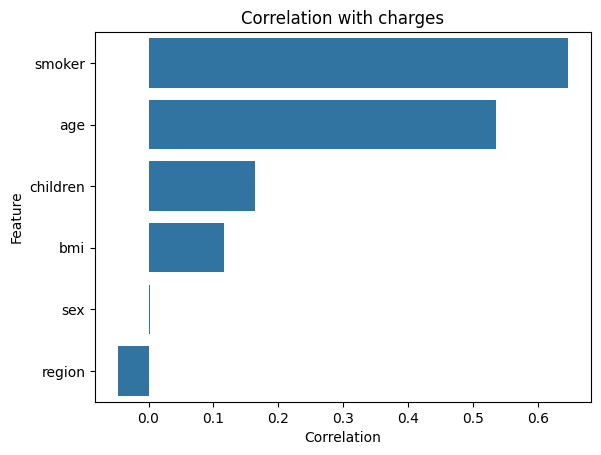

In [14]:
sns.barplot(x=corr.values, y=corr.index)
plt.title('Correlation with charges')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.show()

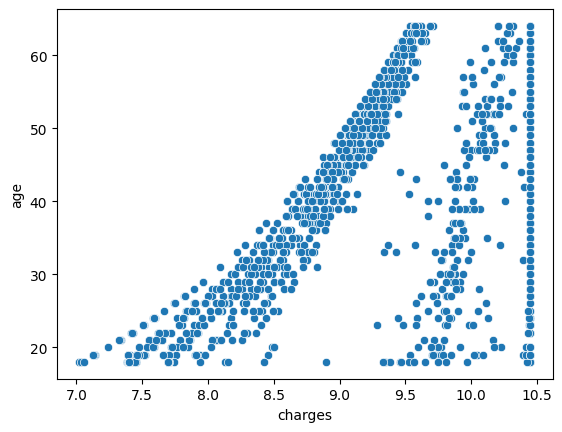

In [15]:
sns.scatterplot(x="charges", y="age", data=data)
plt.show()

# Simple Linear Regresion

In [16]:
## Select Features and Target
#We will use the `bmi` column as the independent variable (X) and `charges` as the target (y).
X = data[['age']]
y = data['charges']


In [17]:
## Split the data into training and testing sets
#We'll use 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
## Create and train the model
#We simple_linear_model = LinearRegression()
simple_linear_model = LinearRegression()
simple_linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
## Make Predictions
y_pred_linear = simple_linear_model.predict(X_test)

In [20]:
## Evaluate the Model
#We will calculate the Mean Squared Error (MSE) and R-squared (R²) score to evaluate performance.
mse = mean_squared_error(y_test, y_pred_linear)
r2 = r2_score(y_test, y_pred_linear)
mae =mean_absolute_error(y_test, y_pred_linear)
print("Mean Squared Error (MSE):", mse)
print("R-squared Score (R²):", r2)
print("Mean Absolute Error:", mae)

Mean Squared Error (MSE): 0.5697569826527062
R-squared Score (R²): 0.3209040280090405
Mean Absolute Error: 0.6023138548862195


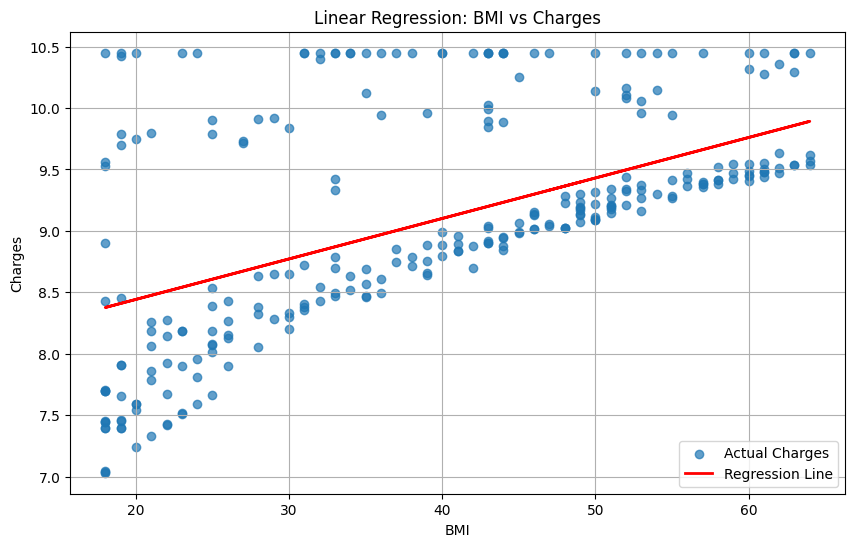

In [21]:
## Visualize the Regression Line
#We will plot the actual data points and the regression line.
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, label='Actual Charges',alpha=0.7)
plt.plot(X_test, y_pred_linear, color='red', linewidth=2, label='Regression Line')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('Linear Regression: BMI vs Charges')
plt.legend()
plt.grid(True)
plt.show()


# Multiple Linear Regression

In [22]:

X = data.drop("charges", axis=1)
Y = data["charges"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [23]:
## Train the Model
#We create and train a multiple linear regression model using the training data.
multiple_linear_model = LinearRegression()
multiple_linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred_mlr = multiple_linear_model.predict(X_test)

In [25]:
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)
mae =mean_absolute_error(y_test, y_pred_mlr)
print(f"Mean Squared Error (MSE): $ {mse_mlr:.2f} $")
print(f"R-squared (R2): $ {r2_mlr:.2f} $")
print("Mean Absolute Error:", mae)

Mean Squared Error (MSE): $ 0.16 $
R-squared (R2): $ 0.81 $
Mean Absolute Error: 0.26277535096094723


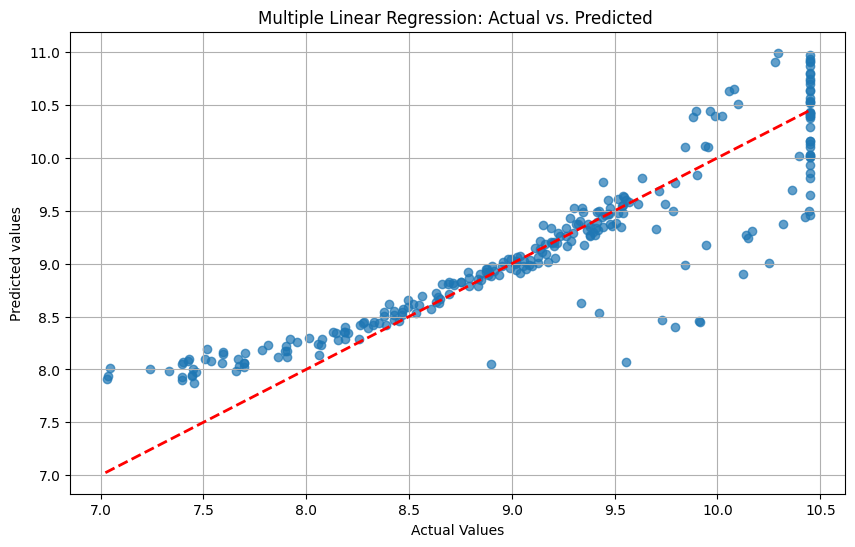

In [26]:
## Visualize the Results
#We plot the actual charges against the predicted ones to see how well the model performs.
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_mlr, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # خط مثالي
plt.title('Multiple Linear Regression: Actual vs. Predicted ')
plt.xlabel('Actual Values')
plt.ylabel('Predicted values')
plt.grid(True)
plt.show()


# Polynomial Regression

In [27]:
degree=2
poly_features = PolynomialFeatures(degree=degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)


In [28]:
polynomial_model = LinearRegression()
polynomial_model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
y_pred_poly = polynomial_model.predict(X_test_poly)

In [30]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
mae =mean_absolute_error(y_test, y_pred_poly)
print(f"Mean Squared Error (MSE): $ {mse_poly:.2f} $")
print(f"R-squared (R2): $ {r2_poly:.2f} $")
print("Mean Absolute Error:", mae)


Mean Squared Error (MSE): $ 0.10 $
R-squared (R2): $ 0.88 $
Mean Absolute Error: 0.1943770244558469


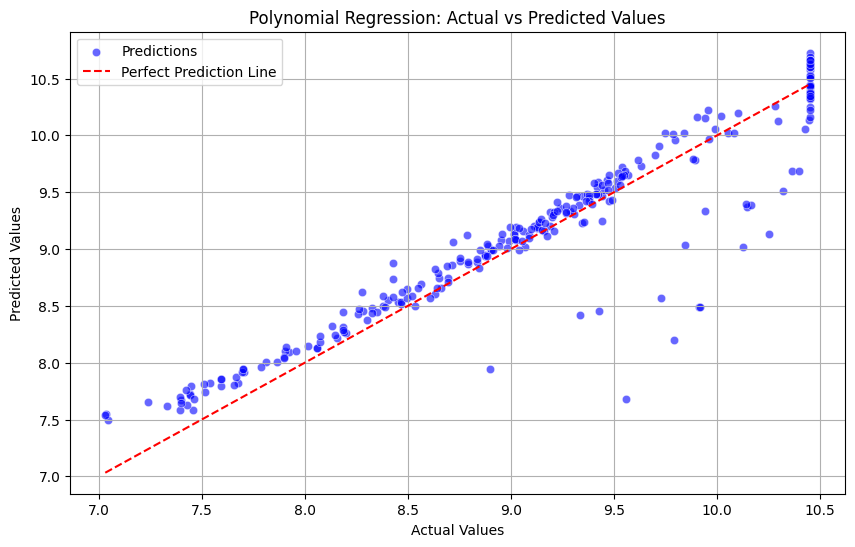

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_poly, color='blue', label='Predictions', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction Line')
plt.title('Polynomial Regression: Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

# Support Vector Regression (SVR)

In [32]:
pipeline = Pipeline(steps=[
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['rbf'],
    'svr__C': [100, 1000, 10000],
    'svr__gamma': [0.01, 0.1, 1]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_svr_model = grid_search.best_estimator_
print(f"Best SVR Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best SVR Parameters: {'svr__C': 100, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}


In [33]:
 # التنبؤ
y_pred_SVR = best_svr_model.predict(X_test)

In [34]:
mse_svr = mean_squared_error(y_test, y_pred_SVR)
mae_svr = mean_absolute_error(y_test, y_pred_SVR)
r2_svr = r2_score(y_test, y_pred_SVR)

print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"R-squared (R2): {r2_svr:.4f}")

Mean Squared Error (MSE): 0.12
Mean Absolute Error (MAE): 0.17
R-squared (R2): 0.8577


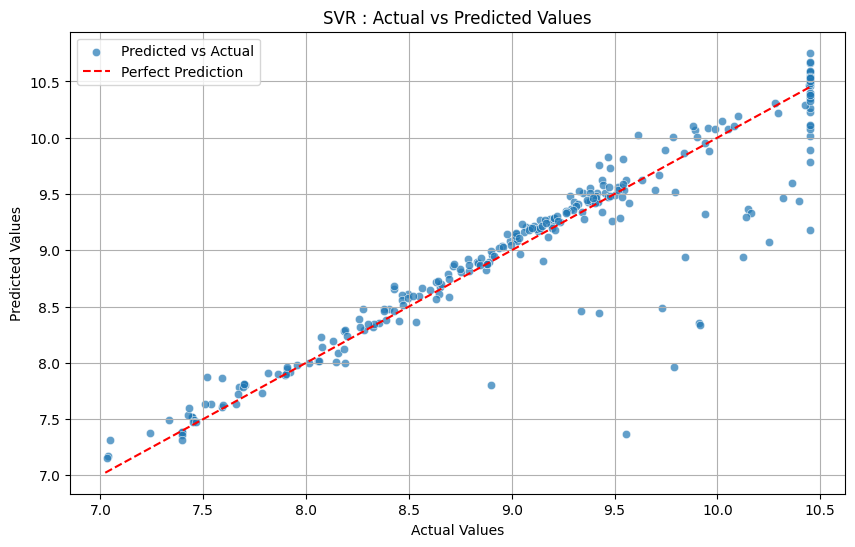

In [35]:
# رسم القيم الحقيقية مقابل القيم المتنبأ بها باستخدام Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_SVR, label='Predicted vs Actual',alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.title(f'SVR : Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid()
plt.show()


# Decision tree regression

In [36]:
# بتخلي التقسيم ثابت عشان تكون النتايج ثابته
# مفيد لو عايزه تعيدي التجربه او تقارني بين النماذج
model=DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [37]:
y_pred=model.predict(X_test)

In [38]:
# evaluate the model
#بستخدم 3 مقاييس مختلفه للتقييم
mse = mean_squared_error(y_test, y_pred)
mae =mean_absolute_error(y_test, y_pred)
r2_Decission_tree= r2_score(y_test, y_pred)
print(f'Decision Tree Regression - MSE: {mse}, MAE: {mae}, R²: {r2} ')

Decision Tree Regression - MSE: 0.27478249438435665, MAE: 0.22334803346852608, R²: 0.3209040280090405 


C:\Users\DELL\AppData\Local\Temp\ipykernel_13468\130268368.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


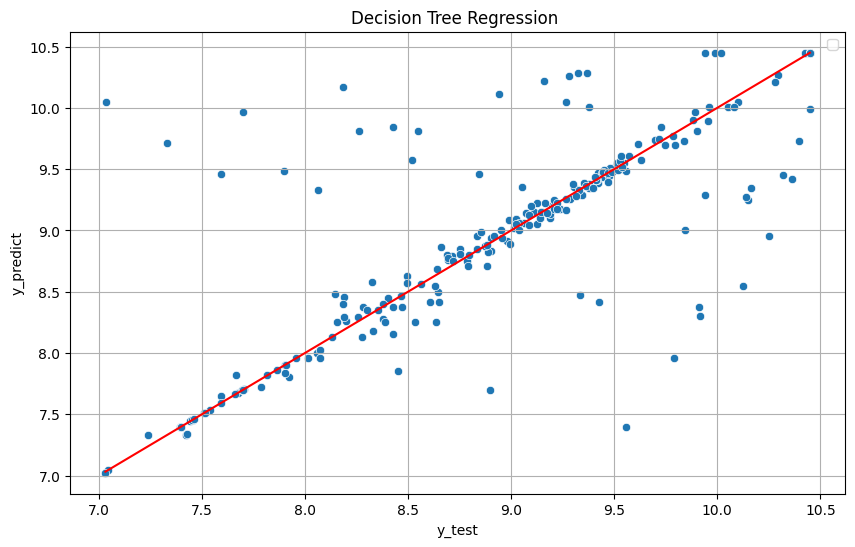

In [39]:
# رسم النتائج باستخدام seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('y_test')
plt.ylabel('y_predict')
plt.title('Decision Tree Regression ')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')  # خط 45 درجة
plt.legend()
plt.grid(True)
plt.show()

# Random Forest Regression

In [40]:
# بناء النموذج وتدريبه
random = RandomForestRegressor(random_state=42)
random.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# التنبؤ
y_pred = random.predict(X_test)

In [42]:
# evaluation the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2_random_forest = r2_score(y_test, y_pred) #الجوده
print(f'Random Forest Regression - MSE: {mse}, MAE: {mae}, R²: {r2} ')

Random Forest Regression - MSE: 0.14095045940232964, MAE: 0.1859488801946991, R²: 0.3209040280090405 


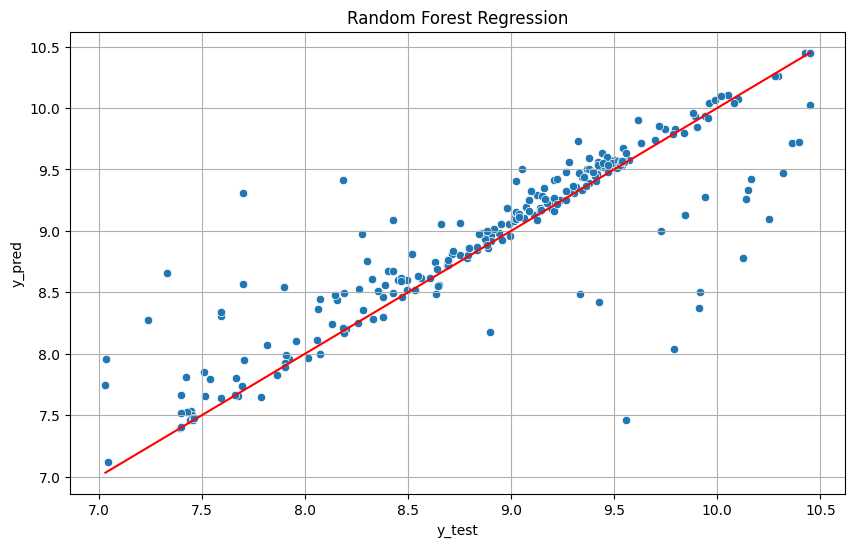

In [43]:
# رسم النتائج
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('Random Forest Regression')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')  # خط مثالي 45°
plt.grid(True)
plt.show()

# Comparing 

C:\Users\DELL\AppData\Local\Temp\ipykernel_13468\669371357.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mse_values, palette='viridis')


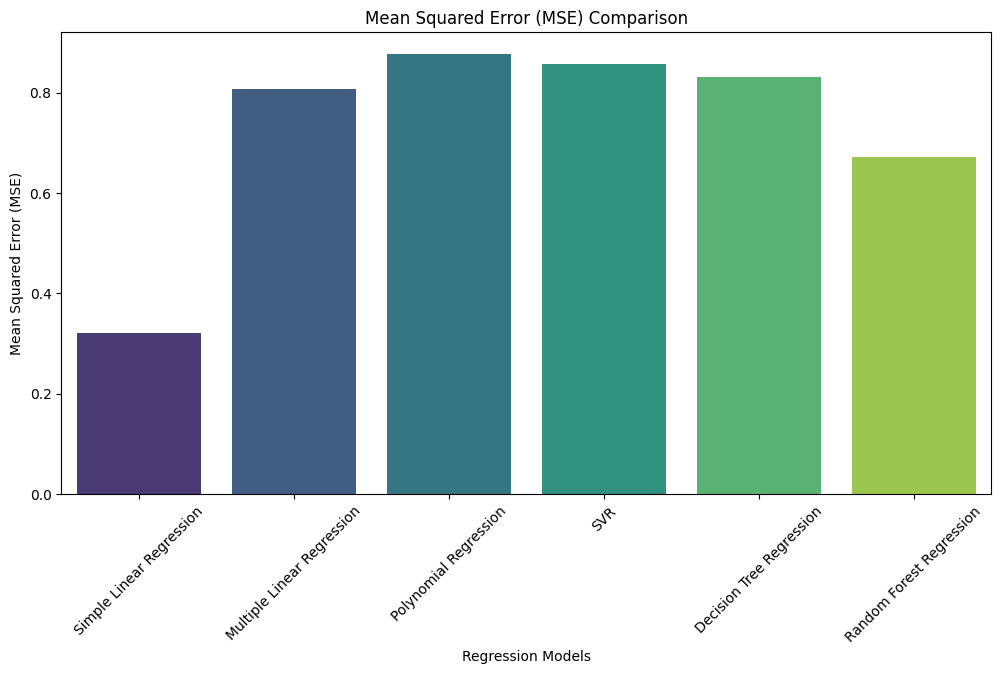

In [44]:
models = ['Simple Linear Regression', 'Multiple Linear Regression', 'Polynomial Regression', 'SVR', 'Decision Tree Regression', 'Random Forest Regression']
mse_values = [r2, r2_mlr, r2_poly, r2_svr,r2_random_forest , r2_Decission_tree]
plt.figure(figsize=(12, 6))
sns.barplot(x=models, y=mse_values, palette='viridis')  
plt.title('Mean Squared Error (MSE) Comparison')
plt.xlabel('Regression Models')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(rotation=45)
plt.show()

# Save The Best Model 

In [45]:
Best_model = polynomial_model
save_he_best_model = 'best_model.pkl'
import joblib
joblib.dump(Best_model, save_he_best_model)

['best_model.pkl']